### Diccionario de datos

En este proyecto, se trabajaró con cinco tablas diferentes.

### 1 La tabla users (datos sobre los usuarios):

user_id: identificador único del usuario.

first_name: nombre del usuario.

last_name: apellido del usuario.

age: edad del usuario (en años).

reg_date: fecha de suscripción (dd, mm, aa).

churn_date: la fecha en la que el usuario dejó de usar el servicio (si el valor es ausente, la tarifa se estaba usando cuando fue extraída esta base de datos).

city: ciudad de residencia del usuario.

plan: nombre de la tarifa.

### 2 La tabla calls (datos sobre las llamadas):

id: identificador único de la llamada.

call_date: fecha de la llamada.

duration: duración de la llamada (en minutos).

user_id: el identificador del usuario que realiza la llamada.

### 3 La tabla messages (datos sobre los SMS):

id: identificador único del SMS.

message_date: fecha del SMS.

user_id: el identificador del usuario que manda el SMS.

### 4 La tabla internet (datos sobre las sesiones web):

id: identificador único de la sesión.

mb_used: el volumen de datos gastados durante la sesión (en megabytes).

session_date: fecha de la sesión web.

user_id: identificador del usuario.

### 5 La tabla plans (datos sobre las tarifas):

plan_name: nombre de la tarifa.

usd_monthly_fee: pago mensual en dólares estadounidenses.

minutes_included: minutos incluidos al mes.

messages_included: SMS incluidos al mes.

mb_per_month_included: datos incluidos al mes (en megabytes).

usd_per_minute: precio por minuto tras exceder los límites del paquete (por ejemplo, si el paquete incluye 100 minutos, el operador cobrará el minuto 101).

usd_per_message: precio por SMS tras exceder los límites del paquete.

usd_per_gb: precio por gigabyte de los datos extra tras exceder los límites del paquete (1 GB = 1024 megabytes).

###  ¿Cuál es la mejor tarifa?

Trabajas como analista para el operador de telecomunicaciones Megaline. La empresa ofrece a sus clientes dos tarifas de prepago, Surf y Ultimate. 

El departamento comercial quiere saber cuál de las tarifas genera más ingresos para poder ajustar el presupuesto de publicidad.

Vas a realizar un análisis preliminar de las tarifas basado en una selección de clientes relativamente pequeña. 

Tendrás los datos de 500 clientes de Megaline: quiénes son los clientes, de dónde son, qué tarifa usan, así como la cantidad de llamadas que hicieron y los mensajes de texto que enviaron en 2018. 

Tu trabajo es analizar el comportamiento de los clientes y determinar qué tarifa de prepago genera más ingresos.

## dar una breve explicación de los objetivos y pasos para este proytecto

### 1.1 Inicialización

In [113]:
# Cargar todas las librerías

from scipy import stats as st
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 1.2 Carga de datos

In [114]:
# Carga los archivos de datos en diferentes DataFrames

megaline_calls_df = pd.read_csv("C:\\Users\\PC\\Documents\\Proyectos\\megaline_calls.csv",)
megaline_users_df = pd.read_csv("C:\\Users\\PC\\Documents\\Proyectos\\Pmegaline_users.csv",)
megaline_plans_df = pd.read_csv("C:\\Users\\PC\\Documents\\Proyectos\\megaline_plans.csv",)
megaline_messages_df = pd.read_csv("C:\\Users\\PC\\Documents\\Proyectos\\megaline_messages.csv",)
megaline_internet_df = pd.read_csv("C:\\Users\\PC\\Documents\\Proyectos\\megaline_internet.csv",)



### 1.3 Preparar los datos

En los siguientes puntos se relaizaran los pasos para dejar los archivos limpios para su análsis.

### 1.4 Tarifas

In [115]:
# Imprime la información general/resumida sobre el DataFrame de las tarifas

megaline_plans_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 260.0+ bytes


In [116]:
# Imprime una muestra de los datos para las tarifas

megaline_plans_df.head()


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


Se observan las tarifas por cada uno de los servicios de acuerdo a los planes que se ofrecen. 

Existe una diferencia considerable entre el plan "surf" y "ultimate" de más del doble en los servicios de mensajes y minutos, pero en megabytes es aproximadamente del doble.

No se observan problemas con la estructurta y los tipos de datos.

### 1.4.1 Corregir datos

In [117]:
# [Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

### 1.4.2 Enrriquecer los datos

In [118]:
# [Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

### 1.5 Usuarios / usuarias 

In [119]:
# Imprime la información general/resumida sobre el DataFrame de usuarios

megaline_users_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [120]:
megaline_users_df.describe()

,user_id,age
count,500.000000,500.000000
mean,1249.500000,45.486000
std,144.481833,16.972269
min,1000.000000,18.000000
25%,1124.750000,30.000000
50%,1249.500000,46.000000
75%,1374.250000,61.000000
max,1499.000000,75.000000


In [121]:
# Imprime una muestra de datos para usuarios

megaline_users_df.head(20)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN
5,1005,Livia,Shields,31,"Dallas-Fort Worth-Arlington, TX MSA",2018-11-29,surf,NaN
6,1006,Jesusa,Bradford,73,"San Francisco-Oakland-Berkeley, CA MSA",2018-11-27,ultimate,2018-12-18
7,1007,Eusebio,Welch,42,"Grand Rapids-Kentwood, MI MSA",2018-07-11,surf,NaN
8,1008,Emely,Hoffman,53,"Orlando-Kissimmee-Sanford, FL MSA",2018-08-03,ultimate,NaN
9,1009,Gerry,Little,19,"San Jose-Sunnyvale-Santa Clara, CA MSA",2018-04-22,surf,NaN


Se observan datos de tipo texto y enteros, así mismo se observan datos vacios en la columna "churn_date". 

Se corriguio el tipo de dato para las columnas "reg_date" y "churn_date" a "dateTime64". 

Se decidio dejar los datos nulos o "NaT" (Not a Time), ya que que no es posible remplazar por un "str" o un "0", por el tipo de dato.

Se separo la columna "city" ya que esta conformada de dos datos la ciudad y el estado.

### 1.5.1 Corregir datos

In [122]:
#[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

megaline_users_df["reg_date"] = pd.to_datetime(megaline_users_df["reg_date"])

megaline_users_df["churn_date"] = pd.to_datetime(megaline_users_df["churn_date"])


In [123]:
user_city = megaline_users_df["city"].str.split(",", expand=True)

megaline_users_df["state"] = user_city[1]

megaline_users_df["city"] = user_city[0]

### 1.5.2 Enrriquecer los datos

In [124]:
# [Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

### 1.6 Llamadas

In [125]:
# Imprime la información general/resumida sobre el DataFrame de las llamadas
megaline_calls_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [126]:
megaline_calls_df.describe()

,user_id,duration
count,137735.000000,137735.000000
mean,1247.658046,6.745927
std,139.416268,5.839241
min,1000.000000,0.000000
25%,1128.000000,1.290000
50%,1247.000000,5.980000
75%,1365.000000,10.690000
max,1499.000000,37.600000


In [127]:
# Imprime una muestra de datos para las llamadas

megaline_calls_df.head(10)


,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22
5,1000_388,1000,2018-12-31,2.20
6,1000_510,1000,2018-12-27,5.75
7,1000_521,1000,2018-12-28,14.18
8,1000_530,1000,2018-12-28,5.77
9,1000_544,1000,2018-12-26,4.40


Se observan datos de tipo texto y enteros.

Se corriguio el tipo de dato para las columnas "call_date" y "churn_date" a "dateTime64".

El tiempo promedio de una llamada al día es de 6.74 min, el max es de 37.6 min y el minimo es de 0 min.



### 1.6.1 Corregir Datos

In [128]:
megaline_calls_df["call_date"] = pd.to_datetime(megaline_calls_df["call_date"])



### 1.6.2 Enrriquecer los datos

### 1.7 Mensajes

In [129]:
# Imprime la información general/resumida sobre el DataFrame de los mensajes
megaline_messages_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [130]:
# Imprime una muestra de datos para los mensajes

megaline_messages_df.head(10)

,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26
5,1000_346,1000,2018-12-29
6,1000_386,1000,2018-12-30
7,1000_413,1000,2018-12-31
8,1000_502,1000,2018-12-27
9,1000_525,1000,2018-12-28


Se observan datos de tipo texto y entero.

Se corrigio el tipo de dato de la columna "message_date".

No se observa otro punto a corregir.

### 1.7.1 Corregir datos

In [131]:
megaline_messages_df["message_date"] = pd.to_datetime(megaline_messages_df["message_date"])

### 1.7.2 Enrriquecer los datos

### 1.8 Internet

In [163]:
# Imprime la información general/resumida sobre el DataFrame de internet

megaline_internet_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  object        
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  float64       
 4   mes           104825 non-null  int32         
 5   gb_used       104825 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int32(1), int64(1), object(1)
memory usage: 4.4+ MB


In [133]:
megaline_internet_df.describe()

,user_id,mb_used
count,104825.000000,104825.000000
mean,1242.496361,366.713701
std,142.053913,277.170542
min,1000.000000,0.000000
25%,1122.000000,136.080000
50%,1236.000000,343.980000
75%,1367.000000,554.610000
max,1499.000000,1693.470000


In [162]:
# Imprime una muestra de datos para el tráfico de internet

megaline_internet_df.head(10)

,id,user_id,session_date,mb_used,mes,gb_used
0,1000_13,1000,2018-12-29,89.86,12,0.087754
1,1000_204,1000,2018-12-31,0.00,12,0.000000
2,1000_379,1000,2018-12-28,660.40,12,0.644922
3,1000_413,1000,2018-12-26,270.99,12,0.264639
4,1000_442,1000,2018-12-27,880.22,12,0.859590
5,1001_0,1001,2018-08-24,284.68,8,0.278008
6,1001_3,1001,2018-12-09,656.04,12,0.640664
7,1001_4,1001,2018-11-04,16.97,11,0.016572
8,1001_10,1001,2018-11-27,135.18,11,0.132012
9,1001_15,1001,2018-12-13,761.92,12,0.744062


Se observan datos de tipo texto y entero.

Se corrigio el tipo de dato para la columna "session_date".


la cantidad promedio de megabytes usados es de 366, el minimo es de 0 mb y el máximo es de 1693 mb.

### 1.8.1 Corregir datos

In [135]:
megaline_internet_df["session_date"] = pd.to_datetime(megaline_internet_df["session_date"])



### 1.8.2 Enriquecer los datos

## 1.9 Estudiar las condiciones de las tarifas

In [136]:
# Imprime las condiciones de la tarifa y asegúrate de que te quedan claras

megaline_plans_df.head()


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


### 1.10 Agregar datos de usuario

In [137]:
# Calcula el número de llamadas hechas por cada usuario al mes. Guarda el resultado.
llamadas_al_mes = megaline_calls_df
llamadas_al_mes["mes"] = llamadas_al_mes["call_date"].dt.month # se agrega una columna que guarde el mes
llamadas_al_mes = llamadas_al_mes.groupby(["user_id", "mes"])["id"].count().reset_index() #se agrupa por el mes por usuario y el recuento del número de llamadas de la culumna "id"
llamadas_al_mes.columns = ["user_id","mes","número de llamadas"] #se camba el titulo de las columnas
llamadas_al_mes.head(20)


,user_id,mes,número de llamadas
0,1000,12,16
1,1001,8,27
2,1001,9,49
3,1001,10,65
4,1001,11,64
5,1001,12,56
6,1002,10,11
7,1002,11,55
8,1002,12,47
9,1003,12,149


In [138]:
# Calcula la cantidad de minutos usados por cada usuario al mes. Guarda el resultado.

minutos_al_mes = megaline_calls_df
minutos_al_mes["mes"] = minutos_al_mes["call_date"].dt.month #agregamos una columna que guarde el mes
minutos_al_mes = minutos_al_mes.groupby(["user_id","mes"])["duration"].sum().reset_index() #se agrupa por el mes por usuario y se suma la cantidad de minútos por mes de la columna "duration"
minutos_al_mes.columns = ["user_id","mes","minutos"]
minutos_al_mes.head(10)


,user_id,mes,minutos
0,1000,12,116.83
1,1001,8,171.14
2,1001,9,297.69
3,1001,10,374.11
4,1001,11,404.59
5,1001,12,392.93
6,1002,10,54.13
7,1002,11,359.76
8,1002,12,363.24
9,1003,12,1041.00


In [139]:
# Calcula el número de mensajes enviados por cada usuario al mes. Guarda el resultado.

mensajes_al_mes = megaline_messages_df
mensajes_al_mes["mes"] = mensajes_al_mes["message_date"].dt.month
mensajes_al_mes = mensajes_al_mes.groupby(["user_id","mes"])["id"].count().reset_index()
mensajes_al_mes.columns = ["user_id","mes","número de mensajes"]

mensajes_al_mes.head(15)



,user_id,mes,número de mensajes
0,1000,12,11
1,1001,8,30
2,1001,9,44
3,1001,10,53
4,1001,11,36
5,1001,12,44
6,1002,10,15
7,1002,11,32
8,1002,12,41
9,1003,12,50


In [140]:
# Calcula el volumen del tráfico de Internet usado por cada usuario al mes. Guarda el resultado.

internet_al_mes = megaline_internet_df
internet_al_mes["mes"] = megaline_internet_df["session_date"].dt.month
internet_al_mes["gb_used"] = internet_al_mes["mb_used"] / 1024 # se agrega una columna que almacena la cantidad de datos utilizados en GB
internet_al_mes = internet_al_mes.groupby(["user_id","mes"])[("gb_used")].sum().reset_index()
internet_al_mes.columns = ["user_id","mes","gb usados"]

internet_al_mes.head(20)



,user_id,mes,gb usados
0,1000,12,1.856904
1,1001,8,6.756982
2,1001,9,13.002754
3,1001,10,21.807119
4,1001,11,18.070605
5,1001,12,18.915215
6,1002,10,6.398447
7,1002,11,18.891680
8,1002,12,14.058828
9,1003,12,26.410293


In [141]:
# Fusiona los datos de llamadas, minutos, mensajes e Internet con base en user_id y month

df_fucionado = pd.merge(llamadas_al_mes,minutos_al_mes,on=["user_id","mes"], how= "outer") # se combinan las tablas y se utiliza un "outer join", ya que si no exite un valor al combinar las filas, dara como resultado un valor nulo en el df combinado

df_fucionado = pd.merge(df_fucionado,mensajes_al_mes, on=["user_id","mes"], how="outer")

df_fucionado = pd.merge(df_fucionado,internet_al_mes, on=["user_id","mes"], how="outer")


df_fucionado.head(20)

,user_id,mes,número de llamadas,minutos,número de mensajes,gb usados
0,1000,12,16.0,116.83,11.0,1.856904
1,1001,8,27.0,171.14,30.0,6.756982
2,1001,9,49.0,297.69,44.0,13.002754
3,1001,10,65.0,374.11,53.0,21.807119
4,1001,11,64.0,404.59,36.0,18.070605
5,1001,12,56.0,392.93,44.0,18.915215
6,1002,10,11.0,54.13,15.0,6.398447
7,1002,11,55.0,359.76,32.0,18.891680
8,1002,12,47.0,363.24,41.0,14.058828
9,1003,12,149.0,1041.00,50.0,26.410293


In [142]:
# Añade la información de la tarifa

df_tarifa = pd.merge(df_fucionado,megaline_users_df[["user_id","plan"]], on= "user_id", how="left") # se combina el df de "users" (se filtra por el user_id y el tipo de plan)

df_tarifa.head(15)


,user_id,mes,número de llamadas,minutos,número de mensajes,gb usados,plan
0,1000,12,16.0,116.83,11.0,1.856904,ultimate
1,1001,8,27.0,171.14,30.0,6.756982,surf
2,1001,9,49.0,297.69,44.0,13.002754,surf
3,1001,10,65.0,374.11,53.0,21.807119,surf
4,1001,11,64.0,404.59,36.0,18.070605,surf
5,1001,12,56.0,392.93,44.0,18.915215,surf
6,1002,10,11.0,54.13,15.0,6.398447,surf
7,1002,11,55.0,359.76,32.0,18.891680,surf
8,1002,12,47.0,363.24,41.0,14.058828,surf
9,1003,12,149.0,1041.00,50.0,26.410293,surf


In [ ]:
# Calcula el ingreso mensual para cada usuario

df_merge = pd.merge(df_tarifa,megaline_plans_df, left_on="plan", right_on="plan_name", how="left") # se combina asociando los nombres de las filas de "plan" y "name_plan"

df_merge["minutos_extra"] = df_merge["minutos"] - df_merge['minutes_included'] # se calcula los minutos por llamada extra
df_merge["minutos_extra"] = df_merge["minutos_extra"].apply(lambda x: x if x > 0 else 0) #se valida que los valores de la columna "minutos_extra" sean mayores a cero, con el método apply indicamos que se aplique la confirmación en cada unos de los valores de la columna
df_merge["minutos_costo_extra"] = df_merge["minutos_extra"] * df_merge['usd_per_minute'] # se calcula el conto de los minutos extra

df_merge["mensajes_extra"] = df_merge["número de mensajes"] - df_merge["messages_included"] # se calcula los mensajes extra
df_merge["mensajes_extra"] = df_merge["mensajes_extra"].apply(lambda x: x if x > 0 else 0)
df_merge["mensajes_costo_extra"] = df_merge["mensajes_extra"] * df_merge["usd_per_message"]


df_merge["mb_per_month_included"] = df_merge["mb_per_month_included"]/1024 # se tranforma de mb a gb
df_merge["datos_extra"] = df_merge["gb usados"] - df_merge["mb_per_month_included"] #se calcula la cantidad de datos utilizados en gb 
df_merge["datos_extra"] = df_merge["datos_extra"].apply(lambda x: x if x > 0 else 0)
df_merge["datos_costo_extra"] = df_merge["datos_extra"] * df_merge["usd_per_gb"] 

df_merge.head(20)

,user_id,mes,número de llamadas,minutos,número de mensajes,gb usados,plan,messages_included,mb_per_month_included,minutes_included,...,usd_per_gb,usd_per_message,usd_per_minute,plan_name,minutos_extra,minutos_costo_extra,mensajes_extra,mensajes_costo_extra,datos_extra,datos_costo_extra
0,1000,12,16.0,116.83,11.0,1.856904,ultimate,1000,30.0,3000,...,7,0.01,0.01,ultimate,0.0,0.00,0.0,0.00,0.000000,0.000000
1,1001,8,27.0,171.14,30.0,6.756982,surf,50,15.0,500,...,10,0.03,0.03,surf,0.0,0.00,0.0,0.00,0.000000,0.000000
2,1001,9,49.0,297.69,44.0,13.002754,surf,50,15.0,500,...,10,0.03,0.03,surf,0.0,0.00,0.0,0.00,0.000000,0.000000
3,1001,10,65.0,374.11,53.0,21.807119,surf,50,15.0,500,...,10,0.03,0.03,surf,0.0,0.00,3.0,0.09,6.807119,68.071191
4,1001,11,64.0,404.59,36.0,18.070605,surf,50,15.0,500,...,10,0.03,0.03,surf,0.0,0.00,0.0,0.00,3.070605,30.706055
5,1001,12,56.0,392.93,44.0,18.915215,surf,50,15.0,500,...,10,0.03,0.03,surf,0.0,0.00,0.0,0.00,3.915215,39.152148
6,1002,10,11.0,54.13,15.0,6.398447,surf,50,15.0,500,...,10,0.03,0.03,surf,0.0,0.00,0.0,0.00,0.000000,0.000000
7,1002,11,55.0,359.76,32.0,18.891680,surf,50,15.0,500,...,10,0.03,0.03,surf,0.0,0.00,0.0,0.00,3.891680,38.916797
8,1002,12,47.0,363.24,41.0,14.058828,surf,50,15.0,500,...,10,0.03,0.03,surf,0.0,0.00,0.0,0.00,0.000000,0.000000
9,1003,12,149.0,1041.00,50.0,26.410293,surf,50,15.0,500,...,10,0.03,0.03,surf,541.0,16.23,0.0,0.00,11.410293,114.102930


In [144]:

df_merge["ingreso_mensual"] = df_merge["usd_monthly_pay"] + df_merge["minutos_costo_extra"] + df_merge["mensajes_costo_extra"] + df_merge["datos_costo_extra"] # se suma el costo del plan mas los servicios extra
df_merge["ingreso_mensual"] = df_merge["ingreso_mensual"].round(2)
print(df_merge[['user_id', 'mes', 'plan', 'ingreso_mensual']].head(20))



    user_id  mes      plan  ingreso_mensual
0      1000   12  ultimate            70.00
1      1001    8      surf            20.00
2      1001    9      surf            20.00
3      1001   10      surf            88.16
4      1001   11      surf            50.71
5      1001   12      surf            59.15
6      1002   10      surf            20.00
7      1002   11      surf            58.92
8      1002   12      surf            20.00
9      1003   12      surf           150.33
10     1004    5      surf            20.00
11     1004    6      surf            71.88
12     1004    7      surf           109.42
13     1004    8      surf           143.26
14     1004    9      surf            54.11
15     1004   10      surf            20.00
16     1004   11      surf            83.39
17     1004   12      surf            78.88
18     1005   12      surf            37.38
19     1006   11  ultimate            70.00


## 1.11  Estudia el comportamiento de usuario

### 1.11.1 Llamadas

In [145]:
# Compara la duración promedio de llamadas por cada plan y por cada mes. Traza un gráfico de barras para visualizarla.

duracion_promedio = megaline_calls_df.merge(megaline_users_df[["user_id","plan"]], on="user_id", how="left") #combinamos el df "calls" y "users"

duracion_promedio["mes"] = duracion_promedio["call_date"].dt.month #utilizamos el atributo "dt" para obtener una columna con el número del mes de acuerdo a la fecha de la columna "call_date"

In [146]:
llamadas_promedio = duracion_promedio.groupby(["mes", "plan"])["duration"].mean().unstack() #agrupamos el promedio de duración de llamadas por "plan" y "mes", se utiliza la función unstack() para combertir los dos tipos de plan en columnas (transponer). 

llamadas_promedio.head(15)

plan,surf,ultimate
mes,,
1,6.428000,6.541518
2,6.906175,6.517230
3,6.696919,6.210906
4,6.799918,6.659990
5,6.769200,6.662443
6,6.846812,6.705188
7,6.721710,6.879085
8,6.726164,6.613484
9,6.728684,6.770040


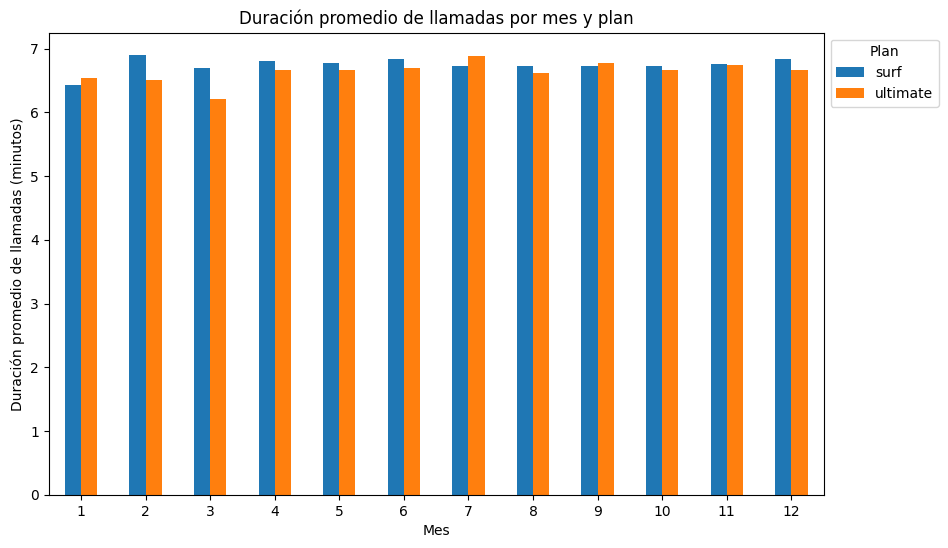

In [147]:
# Graficar el promedio de duración de llamadas por plan y mes
llamadas_promedio.plot(kind='bar', 
                        xlabel= "Mes",
                        ylabel="Duración promedio de llamadas (minutos)",
                        title= "Duración promedio de llamadas por mes y plan",
                        legend = "plan",
                        rot = 0,
                        figsize = (10, 6)
                        
                        
                        )
plt.legend(title='Plan', loc='upper left', bbox_to_anchor=(1, 1)) # Mostramos la leyenda fuera del gráfico
plt.show()

In [148]:
# Compara el número de minutos mensuales que necesitan los usuarios de cada plan. Traza un histograma.

merge_min_mensual = megaline_calls_df.merge(megaline_users_df[["user_id","plan"]], on="user_id", how="left")

merge_min_mensual["mes"] = merge_min_mensual["call_date"].dt.month

minutos_promedio = merge_min_mensual.groupby(["user_id","plan","mes"])["duration"].sum().reset_index()

minutos_promedio.head(20)


,user_id,plan,mes,duration
0,1000,ultimate,12,116.83
1,1001,surf,8,171.14
2,1001,surf,9,297.69
3,1001,surf,10,374.11
4,1001,surf,11,404.59
5,1001,surf,12,392.93
6,1002,surf,10,54.13
7,1002,surf,11,359.76
8,1002,surf,12,363.24
9,1003,surf,12,1041.00


In [149]:
surf_min = minutos_promedio[minutos_promedio["plan"] == "surf"]["duration"] # separamos los planes

ultimate_min = minutos_promedio[minutos_promedio["plan"] == "ultimate"]["duration"]

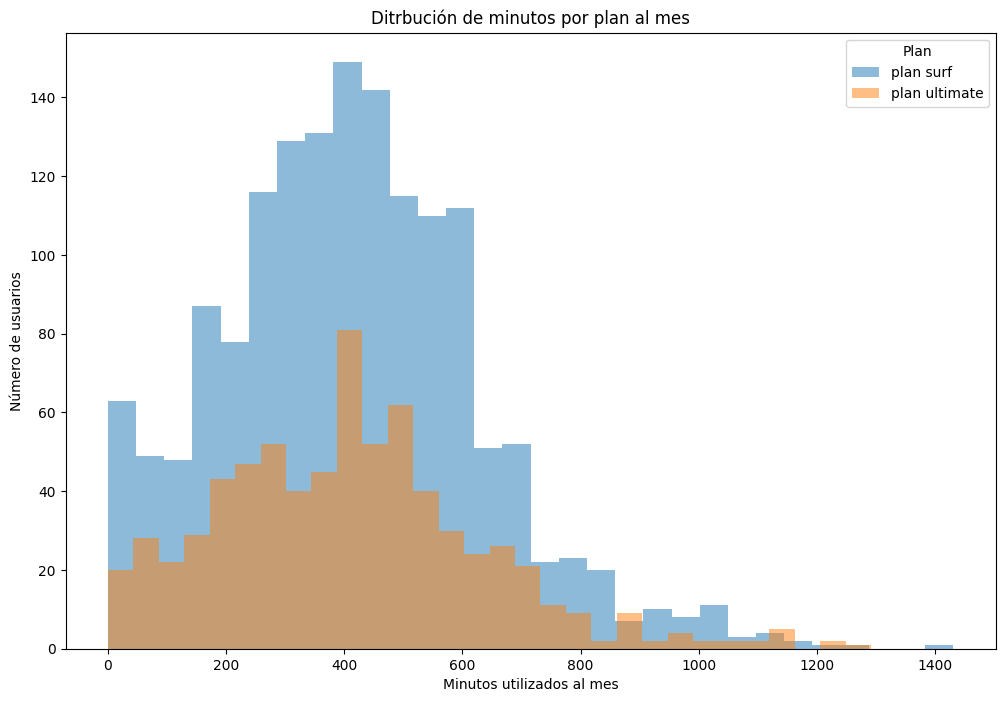

In [150]:
surf_min.plot(kind="hist",
                bins = 30,
                figsize= (12,8),
                title= "Ditrbución de minutos por plan al mes",
                xlabel = "Minutos utilizados al mes",
                ylabel = "Número de usuarios",
                alpha = 0.5,
                label = "plan surf"
                )
ultimate_min.plot(kind="hist",
                    bins = 30,
                    alpha = 0.5,
                    figsize= (12,8),
                    title= "Ditrbución de minutos por plan al mes",
                    xlabel = "Minutos utilizados al mes",
                    ylabel = "Número de usuarios",
                    label = "plan ultimate"
                    )
plt.legend(title='Plan')
plt.show()

In [151]:
# Calcula la media y la varianza de la duración mensual de llamadas.

merge_media_var = megaline_calls_df.merge(megaline_users_df[["user_id","plan"]], on="user_id", how="left")

merge_media_var["mes"] = merge_media_var["call_date"].dt.month

media_var = merge_media_var.groupby(["plan","mes"])["duration"].agg(["mean","var"]).reset_index() #se utiliza el método "agg" par apoder palicar dos operaciones númericas.

media_var.head(24)


,plan,mes,mean,var
0,surf,1,6.428000,28.208311
1,surf,2,6.906175,35.218169
2,surf,3,6.696919,32.393177
3,surf,4,6.799918,33.406473
4,surf,5,6.769200,34.617366
5,surf,6,6.846812,35.141490
6,surf,7,6.721710,33.461154
7,surf,8,6.726164,33.951388
8,surf,9,6.728684,34.649189
9,surf,10,6.722302,33.793825


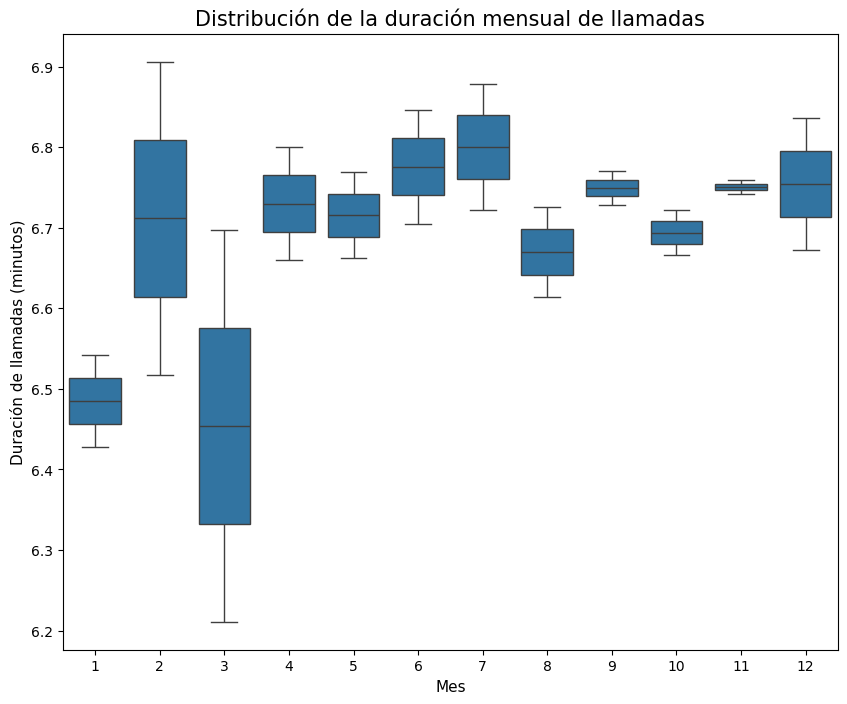

In [152]:
# Traza un diagrama de caja para visualizar la distribución de la duración mensual de llamadas
plt.figure(figsize=(10,8))
sns.boxplot(x= "mes", 
            y= "mean", 
            data = media_var
            )

plt.title('Distribución de la duración mensual de llamadas', fontsize=15)
plt.xlabel('Mes', fontsize=11)
plt.ylabel('Duración de llamadas (minutos)', fontsize=11)

plt.show()


### Conclusión

El comportamiento de los usuarios es bastante similar entre ambos planes, en términos de la duración promedio de las llamadas. Aunque los usuarios de "Surf" tienen límites en los minutos que pueden usar, esto no parece afectar la duración de sus llamadas en comparación con los usuarios de "Ultimate". Con esto podemos concluir que ambos tipos de usuarios tienen patrones de uso similares, independientemente de las restricciones del plan.

### 1.11.2 Mensajes

In [153]:
# Comprara el número de mensajes que tienden a enviar cada mes los usuarios de cada plan

numero_sms_plan = df_merge.groupby(["mes","plan"])["número de mensajes"].mean().unstack() #utilizamos el df combinado del punto 1.10


numero_sms_plan.head(24)

plan,surf,ultimate
mes,,
1,21.000000,20.666667
2,21.600000,25.166667
3,21.937500,34.714286
4,24.166667,28.937500
5,33.017857,44.333333
6,33.616438,36.289474
7,35.945055,41.212766
8,37.596774,47.929825
9,39.523179,45.901408


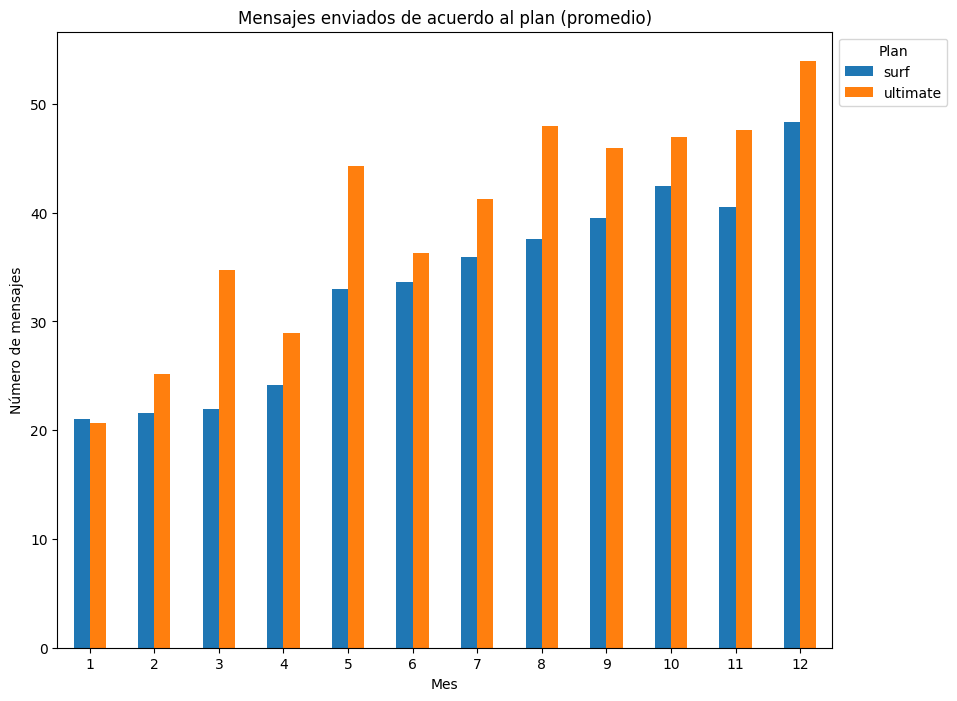

In [154]:
numero_sms_plan.plot(kind='bar', 
                        xlabel= "Mes",
                        ylabel="Número de mensajes",
                        title= "Mensajes enviados de acuerdo al plan (promedio)",
                        legend = "plan",
                        rot = 0,
                        figsize = (10, 8)
                        
                        
                        )
plt.legend(title='Plan', loc='upper left', bbox_to_anchor=(1, 1)) # Mostramos la leyenda fuera del gráfico
plt.show()

### Conclusión.

En promedio los usuarios con el plan "ultimate" tienden a enviar más mensajes que los usuarios con un plan "surf". Con esto podemos afirmar que los usuarios con el plan "ultimate" aprovechan el mayor acceso al servicio, sin dejar de ser moderada, mientras que los usuarios con el plan "surf" tienden a ajustarse a la cantidad limitada de mensajes. Tomando como referencia el gráfico, si existe una diferencia en el comportamiento dependiendo del plan.

### 1.11.3 Internet

In [155]:
# Compara la cantidad de tráfico de Internet consumido por usuarios por plan

cantidad_datos_plan = df_merge.groupby(["mes","plan"])["gb usados"].mean().unstack()

cantidad_datos_plan.head(24)


plan,surf,ultimate
mes,,
1,4.760605,6.755950
2,11.893402,16.727352
3,13.032656,17.892108
4,11.942167,15.743803
5,13.788797,16.234846
6,15.257487,14.978439
7,16.526820,15.961664
8,16.711157,17.397188
9,16.286521,16.572138


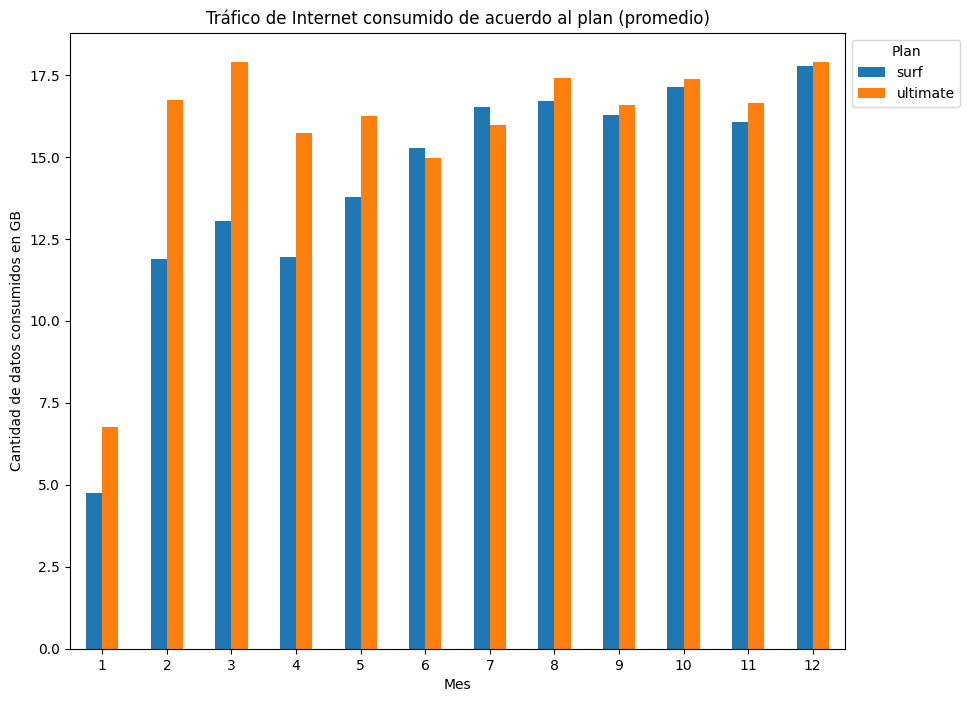

In [156]:
cantidad_datos_plan.plot(kind='bar', 
                        xlabel= "Mes",
                        ylabel="Cantidad de datos consumidos en GB",
                        title= "Tráfico de Internet consumido de acuerdo al plan (promedio)",
                        legend = "plan",
                        rot = 0,
                        figsize = (10, 8)
                        
                        
                        )
plt.legend(title='Plan', loc='upper left', bbox_to_anchor=(1, 1)) # Mostramos la leyenda fuera del gráfico
plt.show()

### Conclusión

En promedio se visualiza un mayor consumo de gb de intrenet para los usurios del plan "ultimate", ya que en este plan existe una mayor cantidad de gb, en caso contrario los usuarios con el plan "surf" tienden a consumir menos cantidad de gb
debido a la restricción del mismo plan. Tomando como referencia el gráfico si existe una diferencia en el tráfico de internet de acuerdo el plan.

### 1.12 Ingreso

In [157]:
ingresos_por_plan = df_merge.groupby("plan")["ingreso_mensual"]

ingresos_por_plan.describe()

,count,mean,std,min,25%,50%,75%,max
plan,,,,,,,,
surf,1573.0,57.293764,53.735935,20.0,20.0,36.68,76.85,581.33
ultimate,720.0,72.116069,10.768846,70.0,70.0,70.00,70.00,178.52


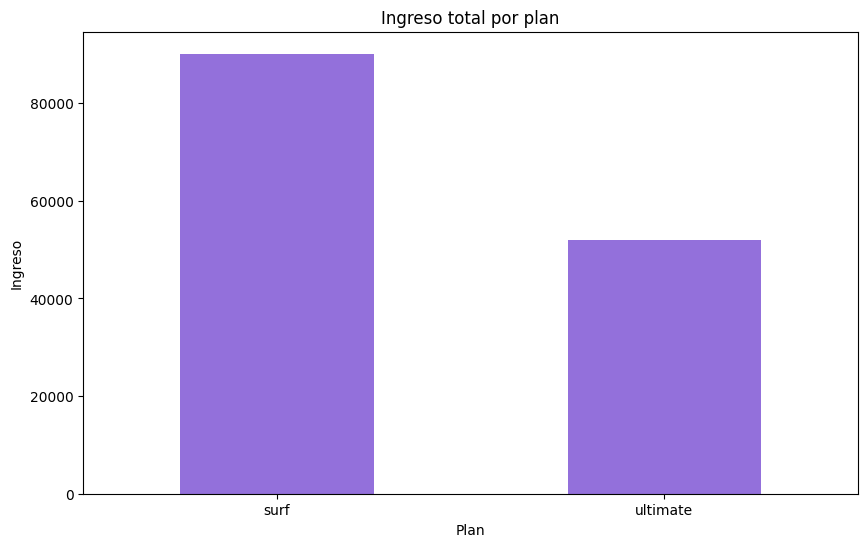

In [158]:
ingreso_total_por_plan = df_merge.groupby("plan")["ingreso_mensual"].sum()
ingreso_total_por_plan.plot(kind="bar",
                title="Ingreso total por plan",
                xlabel="Plan",
                ylabel="Ingreso",
                figsize=(10,6),
                color='mediumpurple',
                rot= 0,
                
                )

plt.show()


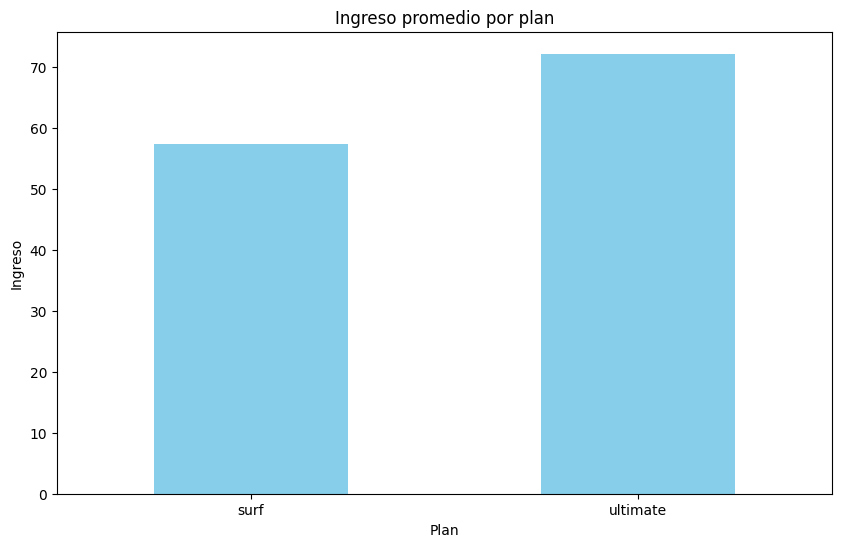

In [159]:
ingreso_promedio_por_plan = df_merge.groupby("plan")["ingreso_mensual"].mean()

ingreso_promedio_por_plan.plot(kind="bar",
                title="Ingreso promedio por plan",
                xlabel="Plan",
                ylabel="Ingreso",
                figsize=(10,6),
                color='skyblue',
                rot= 0,
                
                )

plt.show()

### Conclusión.

El ingreso total del plan "surf" es mayor, esto debido a la cantidad de usuarios y en cierta medida a los cargos adicionales al consumir más alla de lo ofrecido por el plan.

En promedio el plan "ultimate" genera un mayor cantidad de ingresos debido a que tiene una mayor tarifa de cobro, y con lo observado en gráficos anteriores los usurios del plan "surf" no generan cargos adicionales.
Por lo tanto el plan "ultimate" es más rentable en terminos de ingresos fijos ya que no genera una variabilidad en los ingresos debido a cargos adicionales.

### 1.13 Prueba las hipótesis estádisticas

In [160]:
# Prueba las hipótesis

plan_ultimate = df_merge[df_merge["plan"]== "ultimate"]["ingreso_mensual"]

plan_surf = df_merge[df_merge["plan"]== "surf"]["ingreso_mensual"]

alpha = 0.5

t_stat, p_value = st.ttest_ind(plan_ultimate,plan_surf,equal_var=False)

print(f"Estadístico t. {t_stat}")
print(f"Valor de p: {p_value}")


if p_value < alpha:
    print("Rechazamos la hipótesis nula. Los ingresos promedio son diferentes entre los dos planes.")
else:
    print("No podemos rechazar la hipótesis nula. No hay evidencia suficiente para afirmar que los ingresos promedio son diferentes entre los dos planes.")



Estadístico t. 10.48944428446655
Valor de p: 4.881957436054138e-25
Rechazamos la hipótesis nula. Los ingresos promedio son diferentes entre los dos planes.


In [161]:
hipotesis_2 = df_merge.merge(megaline_users_df[["user_id", "state",]], on = "user_id", how= "left")

ingreso_promedio_NY_NJ = hipotesis_2[hipotesis_2["state"] == " NY-NJ-PA MSA"]["ingreso_mensual"]
ingreso_promedio_otros = hipotesis_2[hipotesis_2["state"] != " NY-NJ-PA MSA"]["ingreso_mensual"]

alpha = 0.5
t_stat, p_value = st.ttest_ind(ingreso_promedio_NY_NJ,ingreso_promedio_otros,equal_var=False)

print(f"Estadístico t: {t_stat}")
print(f"Valor de p: {p_value}")

if p_value < alpha:
    print("Rechazamos la hipótesis nula. El ingreso promedio en NY-NJ es diferente al de otras regiones.")
else:
    print("No podemos rechazar la hipótesis nula. No hay evidencia suficiente para afirmar que los ingresos promedio son diferentes entre NY-NJ y otras regiones.")


Estadístico t: -2.360064209484091
Valor de p: 0.01860972748884579
Rechazamos la hipótesis nula. El ingreso promedio en NY-NJ es diferente al de otras regiones.


### 1.14 Conclusión general


1 - Distribución de la duración mensual de llamadas

El comportamiento de los usuarios es bastante similar entre ambos planes, en términos de la duración promedio de las llamadas. Aunque los usuarios de "Surf" tienen límites en los minutos que pueden usar, esto no parece afectar la duración de sus llamadas en comparación con los usuarios de "Ultimate". Con esto podemos concluir que ambos tipos de usuarios tienen patrones de uso similares, independientemente de las restricciones del plan.

2 - Proporción de duración de llamadas al mes.

En promedio los usuarios con el plan "ultimate" tienden a enviar más mensajes que los usuarios con un plan "surf". Con esto podemos afirmar que los usuarios con el plan "ultimate" aprovechan el mayor acceso al servicio, sin dejar de ser moderada, mientras que los usuarios con el plan "surf" tienden a ajustarse a la cantidad limitada de mensajes. Tomando como referencia el gráfico, si existe una diferencia en el comportamiento dependiendo del plan.

3 - Proporción de tráfico de internet al mes. 

En promedio se visualiza un mayor consumo de gb de intrenet para los usurios del plan "ultimate", ya que en este plan existe una mayor cantidad de gb, en caso contrario los usuarios con el plan "surf" tienden a consumir menos cantidad de gb
debido a la restricción del mismo plan. Tomando como referencia el gráfico si existe una diferencia en el tráfico de internet de acuerdo el plan.

4 - Análisis de ingresos por plan.

El ingreso total del plan "surf" es mayor, esto debido a la cantidad de usuarios y en cierta medida a los cargos adicionales al consumir más alla de lo ofrecido por el plan.

En promedio el plan "ultimate" genera un mayor cantidad de ingresos debido a que tiene una mayor tarifa de cobro, y con lo observado en gráficos anteriores los usurios del plan "surf" no generan cargos adicionales.
Por lo tanto el plan "ultimate" es más rentable en terminos de ingresos fijos ya que no genera una variabilidad en los ingresos debido a cargos adicionales.


5 - Ingreso por región.

Existe una diferencia en los ingresos promedio entre los usuarios del área NY-NJ y los usuarios de otras regiones.
